# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os
import gc
import polars as pl

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

import boto3
import pyarrow as pa
import pyarrow.parquet as pq
from dotenv import load_dotenv
from threadpoolctl import threadpool_limits
from implicit.als import AlternatingLeastSquares
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
threadpool_limits(1, "blas")
os.environ["OPENBLAS_NUM_THREADS"] = "1"

load_dotenv()
S3_BUCKET = os.environ["S3_BUCKET_NAME"]
S3_ENDPOINT = os.environ.get("S3_ENDPOINT_URL", "https://storage.yandexcloud.net")
S3_KEY = os.environ["AWS_ACCESS_KEY_ID"]
S3_SECRET = os.environ["AWS_SECRET_ACCESS_KEY"]

storage_options = {
    "key": S3_KEY,
    "secret": S3_SECRET,
    "client_kwargs": {"endpoint_url": S3_ENDPOINT},
}
s3 = boto3.client(
    "s3",
    endpoint_url=S3_ENDPOINT,
    aws_access_key_id=S3_KEY,
    aws_secret_access_key=S3_SECRET,
)

DATA_PREFIX = "recsys/data"
REC_PREFIX = "recsys/recommendations"

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("tracks.parquet")
catalog = pd.read_parquet("catalog_names.parquet")

print("tracks:", tracks.shape)
print("catalog_names:", catalog.shape)
tracks.head()

tracks: (1000000, 4)
catalog_names: (1812471, 3)


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [4]:
interactions_pf = pq.ParquetFile("interactions.parquet")
print("interactions rows:", interactions_pf.metadata.num_rows)

interactions_head = next(interactions_pf.iter_batches(batch_size=5)).to_pandas()
interactions_head

interactions rows: 222629898


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
print("tracks dtypes:")
print(tracks.dtypes, "\n")
print("catalog dtypes:")
print(catalog.dtypes, "\n")
print("interactions schema:")
print(interactions_pf.schema_arrow, "\n")
print("catalog types:")
print(catalog["type"].value_counts())

tracks dtypes:
track_id     int64
albums      object
artists     object
genres      object
dtype: object 

catalog dtypes:
id       int64
type    object
name    object
dtype: object 

interactions schema:
user_id: int32
track_id: int32
track_seq: int16
started_at: timestamp[ns]
__index_level_0__: int64
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 797 

catalog types:
type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64


In [6]:
catalog_ids = {
    t: set(catalog.loc[catalog["type"] == t, "id"])
    for t in ["album", "artist", "genre", "track"]
}

for col in ["albums", "artists", "genres"]:
    n_empty = tracks[col].apply(len).eq(0).sum()
    print(f"{col}: треков с пустым списком = {n_empty}")

for col, t in [("albums", "album"), ("artists", "artist"), ("genres", "genre")]:
    used = set(np.unique(np.concatenate(
        tracks.loc[tracks[col].apply(len) > 0, col].to_numpy()
    )))
    print(f"{col}: id вне каталога = {len(used - catalog_ids[t])}")

print("track_id вне каталога:", (~tracks["track_id"].isin(catalog_ids["track"])).sum())
print("дубликаты track_id:", tracks["track_id"].duplicated().sum())

albums: треков с пустым списком = 18
artists: треков с пустым списком = 15369
genres: треков с пустым списком = 3687
albums: id вне каталога = 0
artists: id вне каталога = 0
genres: id вне каталога = 30
track_id вне каталога: 0
дубликаты track_id: 0


# Выводы

**Выводы по этапу 1:**

- `track_id` и id в каталоге уже имеют тип `int64`, менять не потребовалось.
- У части треков пустые списки `albums` (18), `artists` (15 369), `genres` (3 687).
- У 48 345 треков встречались жанры, которых нет в `catalog_names`.
- Пустые списки и неизвестные id заменены на `-1`, в каталог добавлены записи `unknown`.

In [7]:
UNKNOWN_ID = -1

catalog_ids = {
    t: set(catalog.loc[catalog["type"] == t, "id"])
    for t in ["album", "artist", "genre"]
}

def clean_ids(lst, known):
    cleaned = [x for x in lst if x in known]
    return cleaned if cleaned else [UNKNOWN_ID]

for col, t in [("albums", "album"), ("artists", "artist"), ("genres", "genre")]:
    tracks[col] = tracks[col].apply(lambda lst: clean_ids(lst, catalog_ids[t]))

unknown_rows = pd.DataFrame(
    [(UNKNOWN_ID, t, "unknown") for t in ["album", "artist", "genre"]],
    columns=["id", "type", "name"],
)
catalog = pd.concat([catalog, unknown_rows], ignore_index=True)

tracks["track_id"] = tracks["track_id"].astype("int64")
catalog["id"] = catalog["id"].astype("int64")

for col, t in [("albums", "album"), ("artists", "artist"), ("genres", "genre")]:
    print(col, "пустых списков:", tracks[col].apply(len).eq(0).sum())
    used = set(np.unique(np.concatenate(tracks[col].to_numpy())))
    print(col, "id вне каталога:", len(used - catalog_ids[t] - {UNKNOWN_ID}))

albums пустых списков: 0
albums id вне каталога: 0
artists пустых списков: 0
artists id вне каталога: 0
genres пустых списков: 0
genres id вне каталога: 0


In [8]:
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

всего взаимодействий: 222629898

статистика по числу прослушанных треков на пользователя:
count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
dtype: float64


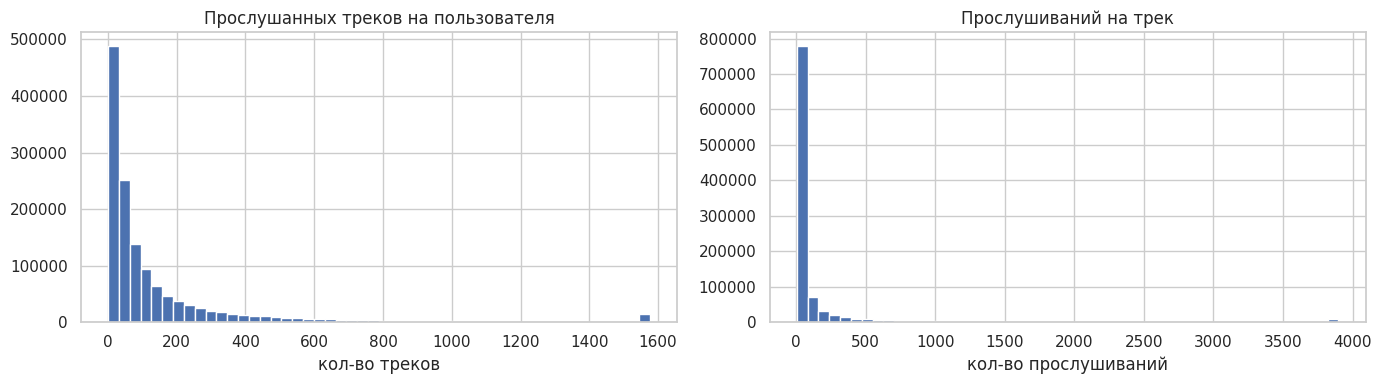

In [9]:
pf = pq.ParquetFile("interactions.parquet")
n_total = pf.metadata.num_rows
print("всего взаимодействий:", n_total)

user_counts = pd.Series(dtype="int64")
track_counts = pd.Series(dtype="int64")
for batch in pf.iter_batches(batch_size=5_000_000, columns=["user_id", "track_id"]):
    chunk = batch.to_pandas()
    user_counts = user_counts.add(chunk["user_id"].value_counts(), fill_value=0)
    track_counts = track_counts.add(chunk["track_id"].value_counts(), fill_value=0)
user_counts = user_counts.astype("int64")
track_counts = track_counts.astype("int64")

print("\nстатистика по числу прослушанных треков на пользователя:")
print(user_counts.describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(user_counts.clip(upper=user_counts.quantile(0.99)), bins=50)
ax[0].set_title("Прослушанных треков на пользователя")
ax[0].set_xlabel("кол-во треков")
ax[1].hist(track_counts.clip(upper=track_counts.quantile(0.99)), bins=50)
ax[1].set_title("Прослушиваний на трек")
ax[1].set_xlabel("кол-во прослушиваний")
plt.tight_layout()
plt.show()

Наиболее популярные треки

In [10]:
track_names = (
    catalog.loc[catalog["type"] == "track", ["id", "name"]]
    .rename(columns={"id": "track_id", "name": "track_name"})
)

top_tracks = track_counts.head(20).reset_index()
top_tracks.columns = ["track_id", "plays"]
top_tracks = top_tracks.merge(track_names, on="track_id", how="left")
top_tracks

,track_id,plays,track_name
0,26,5,Complimentary Me
1,38,8,Momma's Boy
2,135,16,Atticus
3,136,7,24 Hours
4,138,17,Don't Upset The Rhythm (Go Baby Go)
5,139,6,Wild Young Hearts
6,140,24,Sometimes
7,141,343,Never Forget You
8,143,18,Every Now And Then
9,144,49,Leave Me


Наиболее популярные жанры

In [11]:
track_genres = tracks[["track_id", "genres"]].explode("genres")
track_genres = track_genres.rename(columns={"genres": "genre_id"})
track_genres = track_genres.merge(
    track_counts.rename("plays"), left_on="track_id", right_index=True, how="left"
)
track_genres["plays"] = track_genres["plays"].fillna(0)

genre_plays = track_genres.groupby("genre_id")["plays"].sum().sort_values(ascending=False)
genre_names = (
    catalog.loc[catalog["type"] == "genre", ["id", "name"]]
    .rename(columns={"id": "genre_id", "name": "genre"})
)
top_genres = genre_plays.head(20).reset_index().merge(genre_names, on="genre_id", how="left")
top_genres

,genre_id,plays,genre
0,11,55578312,pop
1,75,37799821,rap
2,102,31092013,allrock
3,20,26626241,ruspop
4,3,25303695,rusrap
5,68,20120981,electronics
6,16,16291557,dance
7,2,13166147,rusrock
8,14,12772644,rock
9,47,12437375,metal


Треки, которые никто не прослушал

In [12]:
played = set(track_counts.index)
all_track_ids = set(tracks["track_id"])
never_played = all_track_ids - played

print("всего треков:", len(all_track_ids))
print("прослушанных треков:", len(played))
print("ни разу не прослушано:", len(never_played),
      f"({100 * len(never_played) / len(all_track_ids):.2f}%)")

всего треков: 1000000
прослушанных треков: 1000000
ни разу не прослушано: 0 (0.00%)


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [13]:
items = tracks.copy()
items["n_artists"] = items["artists"].apply(len)
items["n_albums"] = items["albums"].apply(len)
items["n_genres"] = items["genres"].apply(len)

print("items:", items.shape)
items.head()

items: (1000000, 7)


,track_id,albums,artists,genres,n_artists,n_albums,n_genres
0,26,"[3, 2490753]",[16],"[11, 21]",1,2,2
1,38,"[3, 2490753]",[16],"[11, 21]",1,2,2
2,135,"[12, 214, 2490809]",[84],[11],1,3,1
3,136,"[12, 214, 2490809]",[84],[11],1,3,1
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],1,10,1


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
items.to_parquet(
    f"s3://{S3_BUCKET}/{DATA_PREFIX}/items.parquet",
    storage_options=storage_options,
    index=False,
)
print("items.parquet сохранён в S3")

local_events = "events.parquet"
writer = None
for batch in interactions_pf.iter_batches(
    batch_size=2_000_000,
    columns=["user_id", "track_id", "track_seq", "started_at"],
):
    table = pa.Table.from_batches([batch])
    if writer is None:
        writer = pq.ParquetWriter(local_events, table.schema)
    writer.write_table(table)
if writer is not None:
    writer.close()

s3.upload_file(local_events, S3_BUCKET, f"{DATA_PREFIX}/events.parquet")
print("events.parquet сохранён в S3")

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


items.parquet сохранён в S3


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
for name in ["ev", "user_counts", "track_counts", "track_genres", "genre_plays",
             "tracks", "items", "catalog", "interactions_head", "top_tracks",
             "top_genres", "track_names", "genre_names"]:
    globals().pop(name, None)
gc.collect()

60

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
if not os.path.exists("items.parquet"):
    print("Скачиваю items.parquet из S3...")
    s3.download_file(S3_BUCKET, f"{DATA_PREFIX}/items.parquet", "items.parquet")

items = pd.read_parquet("items.parquet")
print("items:", items.shape)

items: (1000000, 7)


In [ ]:
pq.read_table("events.parquet", columns=["user_id", "track_id", "started_at"]).to_pandas().head()

: 

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [3]:
SPLIT_DATE = "2022-12-16"
split_expr = pl.col("started_at") < pl.lit(SPLIT_DATE).str.to_date()

all_items = np.sort(items["track_id"].to_numpy())

all_users = (
    pl.scan_parquet("events.parquet")
    .filter(split_expr)
    .select("user_id").unique()
    .collect(engine="streaming")
)["user_id"].to_numpy()
all_users.sort()

test = (
    pl.scan_parquet("events.parquet")
    .filter(~split_expr)
    .select(["user_id", "track_id"])
    .collect(engine="streaming")
    .to_pandas()
)

print("train пользователей:", len(all_users), "| треков:", len(all_items))
print("test:", len(test), "| test пользователей:", test["user_id"].nunique())

train пользователей: 1342566 | треков: 1000000
test: 13898646 | test пользователей: 783525


In [4]:
n_u, n_i = len(all_users), len(all_items)
split_ts = pd.Timestamp(SPLIT_DATE)

ui = sp.csr_matrix((n_u, n_i), dtype=np.float32)
events_pf = pq.ParquetFile("events.parquet")
for batch in events_pf.iter_batches(
    batch_size=10_000_000, columns=["user_id", "track_id", "started_at"]
):
    ch = batch.to_pandas()
    ch = ch[ch["started_at"] < split_ts]
    rows = np.searchsorted(all_users, ch["user_id"].to_numpy()).astype(np.int32)
    cols = np.searchsorted(all_items, ch["track_id"].to_numpy()).astype(np.int32)
    ui = ui + sp.csr_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, cols)), shape=(n_u, n_i)
    )
    del ch, rows, cols
    gc.collect()
ui.sum_duplicates()

item_plays = np.asarray(ui.sum(axis=0)).ravel()
user_nnz = ui.getnnz(axis=1)

print("матрица взаимодействий:", ui.shape, "ненулевых:", ui.nnz)
print("пользователей:", len(all_users), "| треков:", len(all_items))

матрица взаимодействий: (1342566, 1000000) ненулевых: 208731252
пользователей: 1342566 | треков: 1000000


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [5]:
TOP_N = 100

top_idx = np.argsort(item_plays)[::-1][:TOP_N]
top_popular = pd.DataFrame({
    "track_id": all_items[top_idx],
    "popularity": item_plays[top_idx].astype(np.int64),
})
top_popular["rank"] = np.arange(1, len(top_popular) + 1)

top_popular_list = top_popular["track_id"].to_numpy()
top_popular.head(10)

,track_id,popularity,rank
0,53404,110026,1
1,33311009,101076,2
2,178529,100866,3
3,35505245,95523,4
4,24692821,84153,5
5,795836,83749,6
6,6705392,80608,7
7,32947997,80243,8
8,37384,79512,9
9,45499814,78564,10


In [6]:
top_popular.to_parquet(
    f"s3://{S3_BUCKET}/{REC_PREFIX}/top_popular.parquet",
    storage_options=storage_options,
    index=False,
)
print("top_popular.parquet сохранён в S3:", top_popular.shape)

top_popular.parquet сохранён в S3: (100, 3)


/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


# Персональные

Рассчитаем персональные рекомендации.

In [7]:
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.05,
    iterations=15,
    alpha=1.0,
    random_state=42,
    num_threads=2,
)
with threadpool_limits(1, "blas"):
    als_model.fit(ui)

print("ALS обучен. user_factors:", als_model.user_factors.shape,
      "item_factors:", als_model.item_factors.shape)

100%|██████████| 15/15 [24:43<00:00, 98.88s/it]

ALS обучен. user_factors: (1342566, 50) item_factors: (1000000, 50)


In [ ]:
PERSONAL_N = 30
BATCH = 200_000

total = len(all_users) * PERSONAL_N
rec_users = np.empty(total, dtype=all_users.dtype)
rec_item_ix = np.empty(total, dtype=np.int32)
rec_scores = np.empty(total, dtype=np.float32)

offset = 0
with threadpool_limits(1, "blas"):
    for start in range(0, len(all_users), BATCH):
        u_ix = np.arange(start, min(start + BATCH, len(all_users)))
        ids, scores = als_model.recommend(
            u_ix, ui[u_ix], N=PERSONAL_N, filter_already_liked_items=True
        )
        n = len(u_ix) * PERSONAL_N
        rec_users[offset:offset + n] = np.repeat(all_users[u_ix], PERSONAL_N)
        rec_item_ix[offset:offset + n] = ids.ravel()
        rec_scores[offset:offset + n] = scores.ravel().astype(np.float32)
        offset += n

rec_users = rec_users[:offset]
rec_item_ix = rec_item_ix[:offset]
rec_scores = rec_scores[:offset]

valid = rec_item_ix >= 0
personal_als = pd.DataFrame({
    "user_id": rec_users[valid],
    "track_id": all_items[rec_item_ix[valid]],
    "als_score": rec_scores[valid],
})
personal_als["rank"] = personal_als.groupby("user_id").cumcount() + 1

del rec_users, rec_item_ix, rec_scores, valid
gc.collect()

local_personal = "personal_als.parquet"
personal_als.to_parquet(local_personal, index=False)
s3.upload_file(local_personal, S3_BUCKET, f"{REC_PREFIX}/personal_als.parquet")
print("personal_als.parquet сохранён в S3:", personal_als.shape)
personal_als.head()

In [ ]:
1+1

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
SIMILAR_N = 10
BATCH = 100_000

sim_item_parts, sim_id_parts, sim_score_parts = [], [], []
with threadpool_limits(1, "blas"):
    for start in range(0, len(all_items), BATCH):
        i_ix = np.arange(start, min(start + BATCH, len(all_items)))
        ids, scores = als_model.similar_items(i_ix, N=SIMILAR_N + 1)
        sim_item_parts.append(np.repeat(all_items[i_ix], SIMILAR_N))
        sim_id_parts.append(ids[:, 1:].ravel())
        sim_score_parts.append(scores[:, 1:].ravel())

sim_ids = np.concatenate(sim_id_parts)
valid = sim_ids >= 0
similar = pd.DataFrame({
    "track_id": np.concatenate(sim_item_parts)[valid],
    "similar_track_id": all_items[sim_ids[valid]],
    "score": np.concatenate(sim_score_parts)[valid].astype(np.float32),
})

del sim_item_parts, sim_id_parts, sim_score_parts, sim_ids, valid
gc.collect()

similar.to_parquet(
    f"s3://{S3_BUCKET}/{REC_PREFIX}/similar.parquet",
    storage_options=storage_options,
    index=False,
)
print("similar.parquet сохранён в S3:", similar.shape)
similar.head()

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
n_users_total = len(all_users)
pop_map = pd.Series(item_plays, index=all_items)
user_act_map = pd.Series(user_nnz, index=all_users)
meta = items.set_index("track_id")[["n_artists", "n_genres", "n_albums"]]

def build_features(df):
    df = df.copy()
    df["popularity"] = df["track_id"].map(pop_map).fillna(0).astype(np.float32)
    df["novelty"] = -np.log2((df["popularity"] + 1) / n_users_total).astype(np.float32)
    df["user_activity"] = df["user_id"].map(user_act_map).fillna(0).astype(np.float32)
    df = df.merge(meta, on="track_id", how="left")
    df[["n_artists", "n_genres", "n_albums"]] = (
        df[["n_artists", "n_genres", "n_albums"]].fillna(0).astype(np.float32)
    )
    return df

FEATURES = ["als_score", "popularity", "novelty", "user_activity",
            "n_artists", "n_genres", "n_albums"]

candidates = build_features(personal_als[["user_id", "track_id", "als_score"]])
candidates.head()

In [ ]:
test_users = np.intersect1d(test["user_id"].unique(), all_users)
print("пользователей в test с историей в train:", len(test_users))

test_pos = test.drop_duplicates().copy()
test_pos["target"] = np.int8(1)

cand = candidates[candidates["user_id"].isin(test_users)].merge(
    test_pos, on=["user_id", "track_id"], how="left"
)
cand["target"] = cand["target"].fillna(0).astype(np.int8)
print("кандидатов для ранжирования:", len(cand),
      "| доля положительных:", round(cand["target"].mean(), 4))

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
rng = np.random.default_rng(42)
shuffled = rng.permutation(test_users)
n_train = int(len(shuffled) * 0.7)
train_users_rank = set(shuffled[:n_train].tolist())

is_train = cand["user_id"].isin(train_users_rank)
X_train, y_train = cand.loc[is_train, FEATURES], cand.loc[is_train, "target"]
X_val, y_val = cand.loc[~is_train, FEATURES], cand.loc[~is_train, "target"]

ranker = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50,
)
ranker.fit(X_train, y_train, eval_set=(X_val, y_val))

print("\nважность признаков:")
print(pd.Series(ranker.feature_importances_, index=FEATURES).sort_values(ascending=False))

In [ ]:
TOP_K = 10

candidates["rank_score"] = ranker.predict_proba(candidates[FEATURES])[:, 1]
candidates = candidates.sort_values(["user_id", "rank_score"], ascending=[True, False])

recommendations = candidates.groupby("user_id").head(TOP_K).copy()
recommendations["rank"] = recommendations.groupby("user_id").cumcount() + 1
recommendations = recommendations[["user_id", "track_id", "rank_score", "rank"]]

recommendations.to_parquet(
    f"s3://{S3_BUCKET}/{REC_PREFIX}/recommendations.parquet",
    storage_options=storage_options,
    index=False,
)
print("recommendations.parquet сохранён в S3:", recommendations.shape)
recommendations.head(12)

In [ ]:
1+1

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
TOP_K = 10
EVAL_USERS = 50_000
n_items_total = len(all_items)

pop_prob = (item_plays + 1) / (item_plays.sum() + n_items_total)
novelty_dict = dict(zip(all_items.tolist(), (-np.log2(pop_prob)).tolist()))

rng = np.random.default_rng(0)
eval_users = test_users if len(test_users) <= EVAL_USERS else rng.choice(
    test_users, EVAL_USERS, replace=False
)
eval_set = set(eval_users.tolist())

test_by_user = (
    test[test["user_id"].isin(eval_set)].groupby("user_id")["track_id"].agg(set)
)

def to_dict(df):
    return (
        df.sort_values(["user_id", "rank"])
        .groupby("user_id")["track_id"].apply(list)
        .to_dict()
    )

popular_recs = {u: top_popular_list[:TOP_K].tolist() for u in test_by_user.index}
personal_recs = to_dict(personal_als[personal_als["user_id"].isin(eval_set)])
final_recs = to_dict(recommendations[recommendations["user_id"].isin(eval_set)])

def evaluate(rec_by_user, name):
    recalls, precisions, novelties = [], [], []
    recommended_items = set()
    for u, true_items in test_by_user.items():
        recs = rec_by_user.get(u, [])[:TOP_K]
        if not recs:
            continue
        recommended_items.update(recs)
        hits = len(set(recs) & true_items)
        recalls.append(hits / len(true_items))
        precisions.append(hits / TOP_K)
        novelties.append(np.mean([novelty_dict[t] for t in recs]))
    return {
        "model": name,
        f"recall@{TOP_K}": np.mean(recalls),
        f"precision@{TOP_K}": np.mean(precisions),
        "coverage": len(recommended_items) / n_items_total,
        "novelty": np.mean(novelties),
    }

In [ ]:
metrics = pd.DataFrame([
    evaluate(popular_recs, "top_popular"),
    evaluate(personal_recs, "personal_als"),
    evaluate(final_recs, "ranked (recommendations)"),
]).set_index("model")
metrics

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [ ]:
print("Размеры сохранённых рекомендаций:")
for key in ["top_popular", "personal_als", "similar", "recommendations"]:
    obj = s3.head_object(Bucket=S3_BUCKET, Key=f"{REC_PREFIX}/{key}.parquet")
    print(f"  {REC_PREFIX}/{key}.parquet — {obj['ContentLength'] / 1e6:.2f} MB")

In [ ]:
metrics.round(5)

In [ ]:
1+1